In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
import pandas as pd
import numpy as np
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# --- ZADANIE 1.1 ---
print("--- Zadanie 1.1 ---")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(f"Procent brakujących wartości:\n{missing_pct}\n")

df['Embarked'] = df['Embarked'].fillna('U')


# --- ZADANIE 1.2 ---
df_12 = df.copy()
df_encoded_12 = pd.get_dummies(df_12, columns=['Sex', 'Embarked'], drop_first=False)

for col in df_encoded_12.select_dtypes(include=['bool']).columns:
    df_encoded_12[col] = df_encoded_12[col].astype(int)


# --- ZADANIE 1.3 ---
print("--- Zadanie 1.3 ---")
numeric_df_13 = df_encoded_12.select_dtypes(include=[np.number]).copy()
numeric_df_13['Age'] = numeric_df_13['Age'].fillna(numeric_df_13['Age'].median())


v_input_13 = add_constant(numeric_df_13)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    vif_13 = pd.DataFrame()
    vif_13["feature"] = v_input_13.columns
    vif_13["VIF"] = [variance_inflation_factor(v_input_13.values, i) for i in range(len(v_input_13.columns))]

print(vif_13)


# --- ZADANIE 1.4 ---
print("\n--- Zadanie 1.4: VIF (z ominięciem pułapki) ---")
df_14 = df.copy()
# Tym razem drop_first=True
df_encoded_14 = pd.get_dummies(df_14, columns=['Sex', 'Embarked'], drop_first=True)

for col in df_encoded_14.select_dtypes(include=['bool']).columns:
    df_encoded_14[col] = df_encoded_14[col].astype(int)

numeric_df_14 = df_encoded_14.select_dtypes(include=[np.number]).copy()
numeric_df_14['Age'] = numeric_df_14['Age'].fillna(numeric_df_14['Age'].median())

v_input_14 = add_constant(numeric_df_14)

vif_14 = pd.DataFrame()
vif_14["feature"] = v_input_14.columns
vif_14["VIF"] = [variance_inflation_factor(v_input_14.values, i) for i in range(len(v_input_14.columns))]

print(vif_14)

--- Zadanie 1.1 ---
Procent brakujących wartości:
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.000000
dtype: float64

--- Zadanie 1.3 ---
        feature       VIF
0         const  0.000000
1   PassengerId  1.007984
2      Survived  1.661107
3        Pclass  1.919497
4           Age  1.260871
5         SibSp  1.302978
6         Parch  1.334837
7          Fare  1.651520
8    Sex_female       inf
9      Sex_male       inf
10   Embarked_C       inf
11   Embarked_Q       inf
12   Embarked_S       inf
13   Embarked_U       inf

--- Zadanie 1.4: VIF (z ominięciem pułapki) ---
        feature        VIF
0         const  48.983763
1   PassengerId   1.007984
2      Survived   1.661107
3        Pclass   1.919497
4           Age   1.260871
5         Sib

Liczba rekordów w regionach:
 region
North-America    45933
Asia              1037
Unknown            857
Europe             780
South-America      176
Middle-East         59
Name: count, dtype: int64


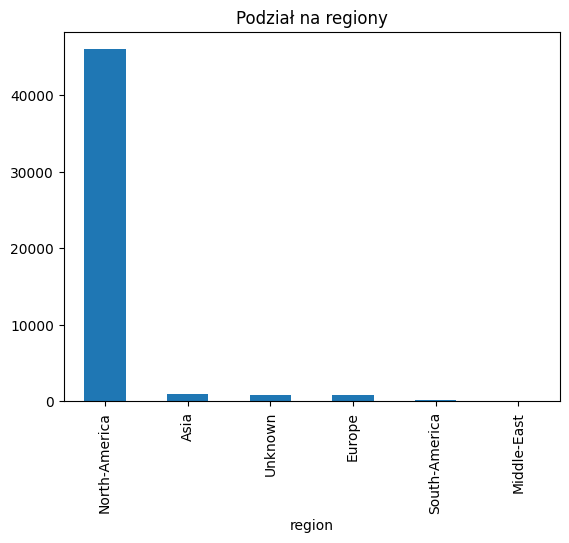


Gotowe! Typ kolumny age: int64
Przykładowe dane:
    age     sex
0   39    Male
1   50    Male
2   38    Male
3   53    Male
4   28  Female


In [10]:
# --- ZADANIE 2.1 ---
import matplotlib.pyplot as plt
df_adult = pd.read_csv('adult.csv')
df_adult = pd.get_dummies(df_adult, columns=['workclass'], drop_first=True)
for col in df_adult.filter(like='workclass_').columns:
    df_adult[col] = df_adult[col].astype(int)

north_america = ['United-States', 'Canada', 'Mexico', 'Puerto-Rico', 'Outlying-US(Guam-USVI-etc)',
                 'Cuba', 'Honduras', 'Jamaica', 'Dominican-Republic', 'Haiti', 'Guatemala',
                 'El-Salvador', 'Nicaragua', 'Trinadad&Tobago']
asia = ['Cambodia', 'India', 'Japan', 'South', 'China', 'Philippines', 'Vietnam', 'Laos', 'Taiwan', 'Thailand', 'Hong']
europe = ['England', 'Germany', 'Greece', 'Italy', 'Poland', 'Portugal', 'Ireland', 'France', 'Hungary', 'Scotland', 'Yugoslavia', 'Holand-Netherlands']
south_america = ['Columbia', 'Ecuador', 'Peru']

def map_to_region(country):
    if country in north_america: return 'North-America'
    if country in asia: return 'Asia'
    if country in europe: return 'Europe'
    if country in south_america: return 'South-America'
    if country == 'Iran': return 'Middle-East'
    return 'Unknown'

df_adult['region'] = df_adult['native-country'].apply(map_to_region)

# Wyświetlenie liczby rekordów i wykres
region_counts = df_adult['region'].value_counts()
print("Liczba rekordów w regionach:\n", region_counts)
region_counts.plot(kind='bar', title='Podział na regiony')
plt.show()

# 3. One-Hot Encoding dla 'region' z omijaniem pułapki
df_adult = pd.get_dummies(df_adult, columns=['region'], drop_first=True)
for col in df_adult.filter(like='region_').columns:
    df_adult[col] = df_adult[col].astype(int)


# --- ZADANIE 2.2 ---
df_adult['age'] = df_adult['age'].fillna(df_adult.groupby('sex')['age'].transform('mean'))


# --- ZADANIE 2.3 ---
df_adult['age'] = df_adult['age'].astype(int)

print("\n Typ kolumny age:", df_adult['age'].dtype)
print("Przykładowe dane:\n", df_adult[['age', 'sex']].head())